## Problem 5A

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

**Load German Dataset**

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    "Status_Checking_Account",
    "Duration_Months",
    "Credit_History",
    "Purpose",
    "Credit_Amount",
    "Savings_Account",
    "Employment_Since",
    "Installment_Rate",
    "Personal_Status_Sex",
    "Other_Debtors",
    "Residence_Since",
    "Property",
    "Age",
    "Other_Installment_Plans",
    "Housing",
    "Existing_Credits",
    "Job",
    "People_Liable",
    "Telephone",
    "Foreign_Worker",
    "Credit_Risk"
]

data = pd.read_csv(url, sep=" ", header=None, names=columns)

data.head()

,Status_Checking_Account,Duration_Months,Credit_History,Purpose,Credit_Amount,Savings_Account,Employment_Since,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,People_Liable,Telephone,Foreign_Worker,Credit_Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


**Create Binary Target Variable**

In [3]:
data["Bad_Risk"] = np.where(data["Credit_Risk"] == 2, 1, 0)

data["Bad_Risk"].value_counts()

Bad_Risk
0    700
1    300
Name: count, dtype: int64

**Prepare X and Y**

In [4]:
X = data.drop(columns=["Credit_Risk", "Bad_Risk"])

y = data["Bad_Risk"]

X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()

,Duration_Months,Credit_Amount,Installment_Rate,Residence_Since,Age,Existing_Credits,People_Liable,Status_Checking_Account_A12,Status_Checking_Account_A13,Status_Checking_Account_A14,...,Property_A124,Other_Installment_Plans_A142,Other_Installment_Plans_A143,Housing_A152,Housing_A153,Job_A172,Job_A173,Job_A174,Telephone_A192,Foreign_Worker_A202
0,6,1169,4,4,67,2,1,False,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,True,False,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,False,False,True,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,False,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,False,False,False,...,True,False,True,False,True,False,True,False,False,False


**Train - Test Split**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((700, 48), (300, 48))

**Fit Log. Reg. Model with Scaling**

In [6]:
logit_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=5000))
])

logit_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](48,)","['Duration_Months','Credit_Amount','Installment_Rate',...,'Job_A174', 'Telephone_A192','Foreign_Worker_A202']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,48
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


**Get Predicted Probabilities**

In [7]:
y_pred_prob = logit_model.predict_proba(X_test)[:, 1]

y_pred_prob[:10]

array([0.02559482, 0.11806872, 0.42713085, 0.10012375, 0.25948674,
       0.11582669, 0.08332431, 0.31831109, 0.38949511, 0.70625965])

**Evaluate the default 0.50 threshold**

In [8]:
threshold = 0.50

y_pred_50 = np.where(y_pred_prob >= threshold, 1, 0)

confusion_matrix(y_test, y_pred_50)

array([[185,  25],
       [ 44,  46]])

**Tru Multiple Thresholds**

In [ ]:
# We will test thresholds from 0.10 to 0.90
thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:
    
    y_pred_threshold = np.where(y_pred_prob >= threshold, 1, 0)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    accuracy = accuracy_score(y_test, y_pred_threshold)
    precision_bad = precision_score(y_test, y_pred_threshold, pos_label=1, zero_division=0)
    recall_bad = recall_score(y_test, y_pred_threshold, pos_label=1)
    f1_bad = f1_score(y_test, y_pred_threshold, pos_label=1)
    
    results.append({
        "Threshold": threshold,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Accuracy": accuracy,
        "Precision Bad Risk": precision_bad,
        "Recall Bad Risk": recall_bad,
        "F1 Bad Risk": f1_bad
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,True Negatives,False Positives,False Negatives,True Positives,Accuracy,Precision Bad Risk,Recall Bad Risk,F1 Bad Risk
0,0.10,74,136,8,82,0.520000,0.376147,0.911111,0.532468
1,0.15,108,102,13,77,0.616667,0.430168,0.855556,0.572491
2,0.20,126,84,14,76,0.673333,0.475000,0.844444,0.608000
3,0.25,143,67,18,72,0.716667,0.517986,0.800000,0.628821
4,0.30,151,59,24,66,0.723333,0.528000,0.733333,0.613953
5,0.35,162,48,28,62,0.746667,0.563636,0.688889,0.620000
6,0.40,170,40,34,56,0.753333,0.583333,0.622222,0.602151
7,0.45,175,35,37,53,0.760000,0.602273,0.588889,0.595506
8,0.50,185,25,44,46,0.770000,0.647887,0.511111,0.571429
9,0.55,193,17,49,41,0.780000,0.706897,0.455556,0.554054


**Add Cost Sensitive Evaluation**

In [11]:
false_positive_cost = 1
false_negative_cost = 5

threshold_results["Total Cost"] = (
    threshold_results["False Positives"] * false_positive_cost
    + threshold_results["False Negatives"] * false_negative_cost
)

threshold_results

,Threshold,True Negatives,False Positives,False Negatives,True Positives,Accuracy,Precision Bad Risk,Recall Bad Risk,F1 Bad Risk,Total Cost
0,0.10,74,136,8,82,0.520000,0.376147,0.911111,0.532468,176
1,0.15,108,102,13,77,0.616667,0.430168,0.855556,0.572491,167
2,0.20,126,84,14,76,0.673333,0.475000,0.844444,0.608000,154
3,0.25,143,67,18,72,0.716667,0.517986,0.800000,0.628821,157
4,0.30,151,59,24,66,0.723333,0.528000,0.733333,0.613953,179
5,0.35,162,48,28,62,0.746667,0.563636,0.688889,0.620000,188
6,0.40,170,40,34,56,0.753333,0.583333,0.622222,0.602151,210
7,0.45,175,35,37,53,0.760000,0.602273,0.588889,0.595506,220
8,0.50,185,25,44,46,0.770000,0.647887,0.511111,0.571429,245
9,0.55,193,17,49,41,0.780000,0.706897,0.455556,0.554054,262


**Find the threshold with the lowest cost**

In [12]:
best_cost_threshold = threshold_results.loc[
    threshold_results["Total Cost"].idxmin()
]

best_cost_threshold

Threshold               0.200000
True Negatives        126.000000
False Positives        84.000000
False Negatives        14.000000
True Positives         76.000000
Accuracy                0.673333
Precision Bad Risk      0.475000
Recall Bad Risk         0.844444
F1 Bad Risk             0.608000
Total Cost            154.000000
Name: 2, dtype: float64

**Find the threshold with the best bad-risk F1 score**

In [13]:
best_f1_threshold = threshold_results.loc[
    threshold_results["F1 Bad Risk"].idxmax()
]

best_f1_threshold

Threshold               0.250000
True Negatives        143.000000
False Positives        67.000000
False Negatives        18.000000
True Positives         72.000000
Accuracy                0.716667
Precision Bad Risk      0.517986
Recall Bad Risk         0.800000
F1 Bad Risk             0.628821
Total Cost            157.000000
Name: 3, dtype: float64

**Plot threshold vs recall for bad borrowers**

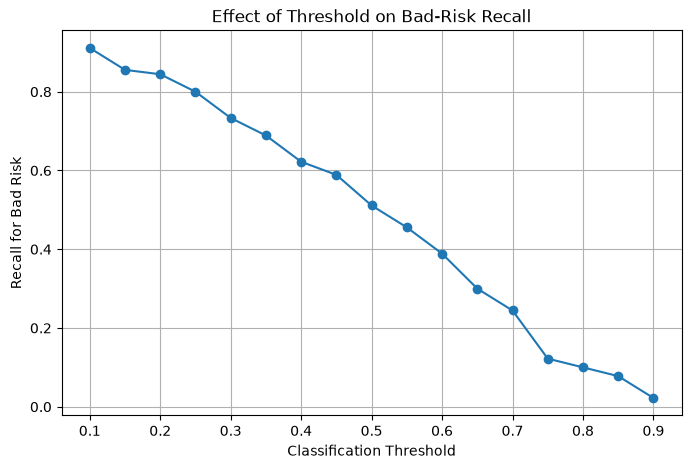

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall Bad Risk"],
    marker="o"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Recall for Bad Risk")
plt.title("Effect of Threshold on Bad-Risk Recall")
plt.grid(True)

plt.show()

**Plot: Threshold v. Total Cost**

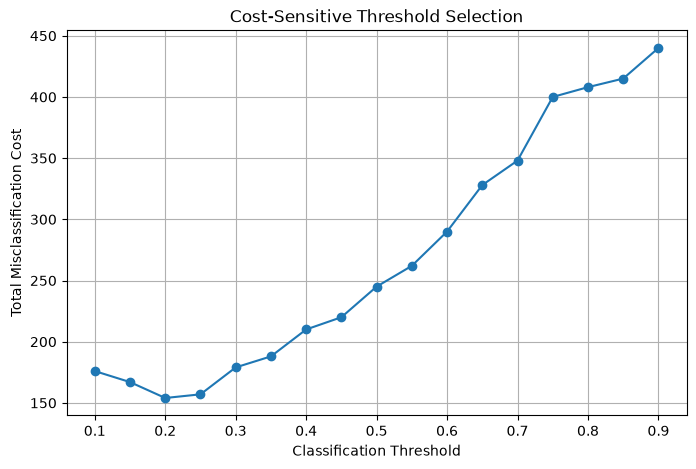

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Total Cost"],
    marker="o"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Total Misclassification Cost")
plt.title("Cost-Sensitive Threshold Selection")
plt.grid(True)

plt.show()

**Compare threshold 0.50 with best-cost threshold**

In [17]:
threshold_50_row = threshold_results[
    np.isclose(threshold_results["Threshold"], 0.50)
]

comparison_thresholds = pd.concat(
    [
        threshold_50_row,
        best_cost_threshold.to_frame().T
    ],
    axis=0
)

comparison_thresholds

,Threshold,True Negatives,False Positives,False Negatives,True Positives,Accuracy,Precision Bad Risk,Recall Bad Risk,F1 Bad Risk,Total Cost
8,0.5,185.0,25.0,44.0,46.0,0.770000,0.647887,0.511111,0.571429,245.0
2,0.2,126.0,84.0,14.0,76.0,0.673333,0.475000,0.844444,0.608000,154.0


### Interpretation of Threshold Tuning Results

This extension examines whether changing the classification threshold improves the credit-risk usefulness of the Logistic Regression model. In the baseline model, a borrower was classified as bad risk if the predicted probability of bad credit risk was at least 0.50. However, in credit-risk applications, missing a bad borrower can be more costly than wrongly rejecting a good borrower.

At the default threshold of 0.50, the model produced 44 false negatives, meaning that 44 actual bad borrowers were incorrectly classified as good borrowers. The recall for bad borrowers was 0.5111, meaning that the model identified only about 51% of actual bad-risk borrowers.

After testing multiple thresholds, the cost-sensitive evaluation selected a threshold of 0.20. At this threshold, false negatives fell from 44 to 14, and recall for bad borrowers increased from 0.5111 to 0.8444. This means that the model became much better at identifying risky borrowers.

The trade-off is that false positives increased from 25 to 84, meaning that more good borrowers were wrongly classified as bad risk. Accuracy also decreased from 0.7700 to 0.6733. However, under the assumed cost structure where a false negative is five times more costly than a false positive, the total misclassification cost decreased from 245 to 154.

Overall, the threshold-tuning exercise shows that the default 0.50 threshold is not necessarily optimal in credit-risk modelling. A lower threshold can be more appropriate when the objective is to reduce the costly mistake of approving bad borrowers.

### Conclusion

Problem 5A shows that classification thresholds play an important role in credit-risk modelling. While the default threshold of 0.50 gives higher accuracy, it misses too many bad borrowers. A lower threshold of 0.20 reduces false negatives substantially and lowers the total cost under the assumed cost structure. This demonstrates that model evaluation should consider business costs and risk priorities, not just accuracy.

## END